<a href="https://colab.research.google.com/github/rt224444/Pen449/blob/main/FACTBOOK11.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/cia_factbook.csv')
display(df.head())

,country,area,birth_rate,death_rate,infant_mortality_rate,internet_users,life_exp_at_birth,maternal_mortality_rate,net_migration_rate,population,population_growth_rate
0,Russia,17098242.0,11.87,13.83,7.08,40853000.0,70.16,34.0,1.69,1.424703e+08,-0.03
1,Canada,9984670.0,10.29,8.31,4.71,26960000.0,81.67,12.0,5.66,3.483484e+07,0.76
2,United States,9826675.0,13.42,8.15,6.17,245000000.0,79.56,21.0,2.45,3.188921e+08,0.77
3,China,9596960.0,12.17,7.44,14.79,389000000.0,75.15,37.0,-0.32,1.355693e+09,0.44
4,Brazil,8514877.0,14.72,6.54,19.21,75982000.0,73.28,56.0,-0.15,2.026568e+08,0.80


In [3]:
display(df.describe())

,area,birth_rate,death_rate,infant_mortality_rate,internet_users,life_exp_at_birth,maternal_mortality_rate,net_migration_rate,population,population_growth_rate
count,2.570000e+02,224.000000,225.000000,224.000000,2.130000e+02,224.000000,184.000000,222.000000,2.380000e+02,233.000000
mean,5.308881e+05,19.659063,7.906978,24.484420,8.311771e+06,71.826875,177.972826,-0.181577,3.229436e+07,1.100858
std,1.696869e+06,9.669575,2.979933,24.077809,3.350725e+07,8.798460,262.508297,11.142682,1.277013e+08,1.418633
min,0.000000e+00,6.720000,1.530000,1.810000,4.640000e+02,49.440000,2.000000,-113.510000,4.800000e+01,-9.730000
25%,6.160000e+02,11.840000,5.930000,6.185000,8.640000e+04,67.000000,20.000000,-2.015000,3.265865e+05,0.260000
50%,5.119700e+04,16.890000,7.630000,13.985000,7.164000e+05,74.360000,65.500000,-0.045000,5.220371e+06,1.020000
75%,3.381450e+05,24.915000,9.450000,38.655000,4.200000e+06,78.292500,240.000000,1.257500,1.826175e+07,1.920000
max,1.709824e+07,46.120000,17.490000,117.230000,3.890000e+08,89.570000,2054.000000,83.820000,1.355693e+09,9.370000


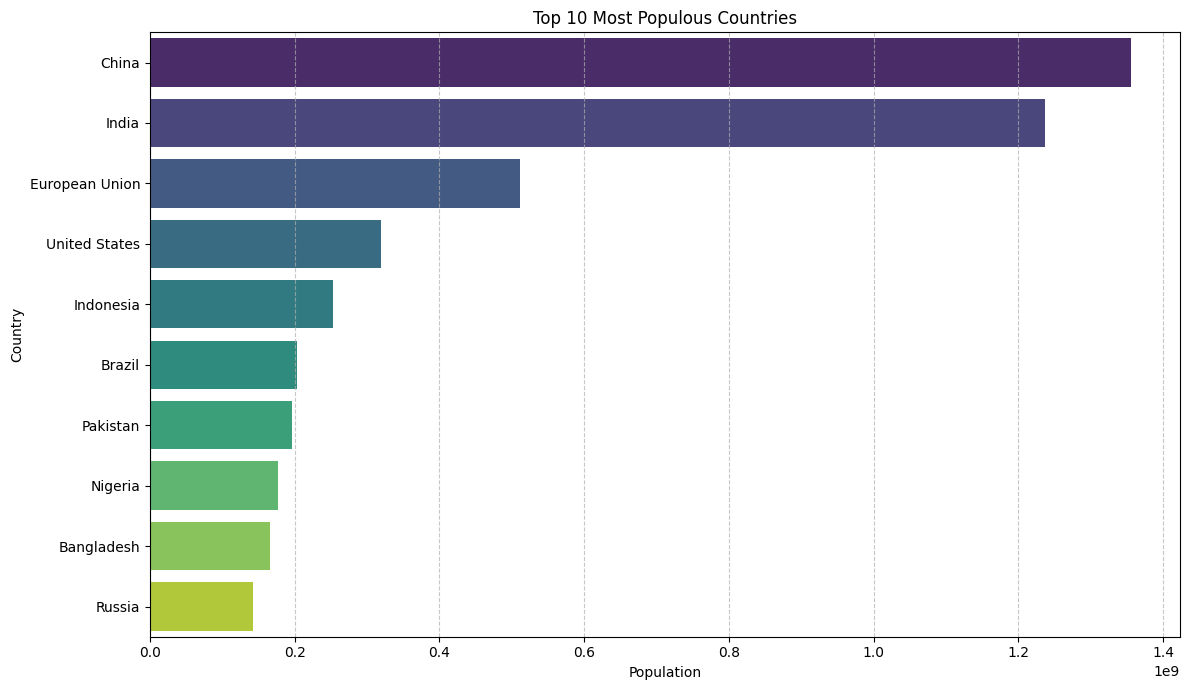

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Sort by population and get the top 10
top_10_population = df.sort_values(by='population', ascending=False).head(10)

# Create the bar chart
plt.figure(figsize=(12, 7))
sns.barplot(x='population', y='country', data=top_10_population, palette='viridis', hue='country', legend=False)

# Add title and labels
plt.title('Top 10 Most Populous Countries')
plt.xlabel('Population')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

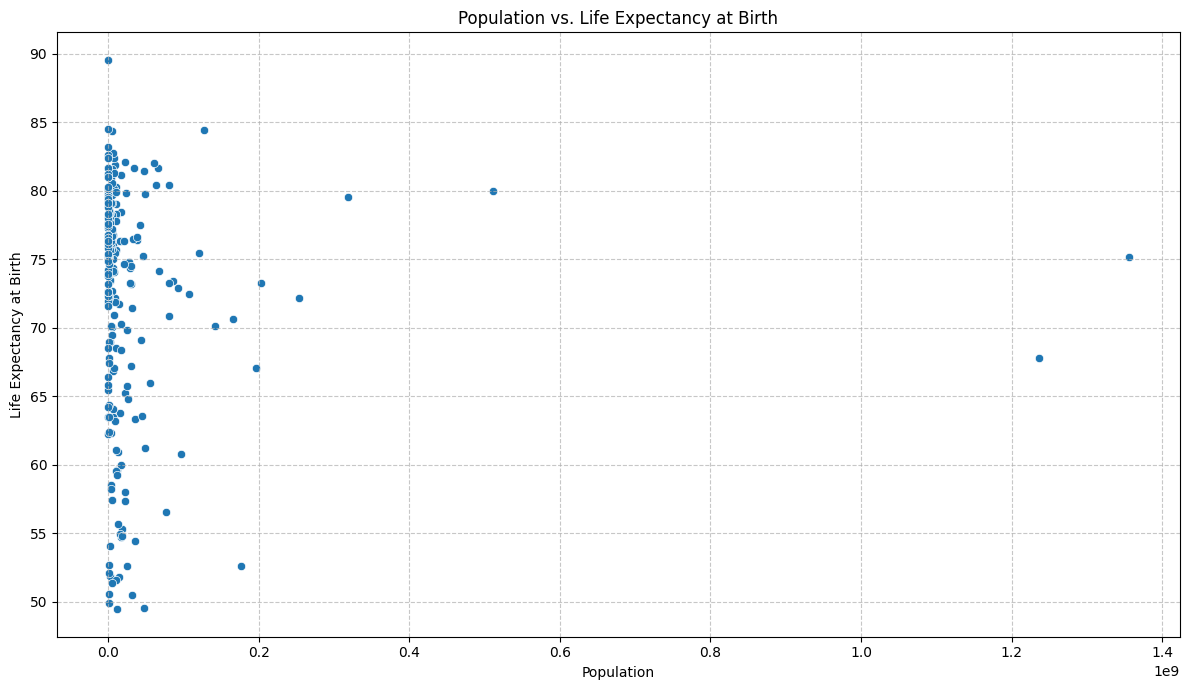

In [6]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='population', y='life_exp_at_birth', data=df)

plt.title('Population vs. Life Expectancy at Birth')
plt.xlabel('Population')
plt.ylabel('Life Expectancy at Birth')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [7]:
# Select only numerical columns
numerical_df = df.select_dtypes(include=['number'])

# Calculate the correlation matrix
correlation_matrix = numerical_df.corr()

# Display the correlation matrix
display(correlation_matrix)

,area,birth_rate,death_rate,infant_mortality_rate,internet_users,life_exp_at_birth,maternal_mortality_rate,net_migration_rate,population,population_growth_rate
area,1.000000,-0.037548,0.092987,-0.010617,0.573478,-0.008539,-0.039868,0.031380,0.461482,-0.007131
birth_rate,-0.037548,1.000000,0.146728,0.873290,-0.155170,-0.843933,0.736407,-0.123979,-0.024971,0.559693
death_rate,0.092987,0.146728,1.000000,0.361531,0.008311,-0.482452,0.339660,-0.075407,-0.001598,-0.168202
infant_mortality_rate,-0.010617,0.873290,0.361531,1.000000,-0.120913,-0.893898,0.788007,-0.094743,0.024678,0.449531
internet_users,0.573478,-0.155170,0.008311,-0.120913,1.000000,0.136051,-0.140623,0.015816,0.762927,-0.086203
life_exp_at_birth,-0.008539,-0.843933,-0.482452,-0.893898,0.136051,1.000000,-0.826769,0.152309,-0.001516,-0.358312
maternal_mortality_rate,-0.039868,0.736407,0.339660,0.788007,-0.140623,-0.826769,1.000000,-0.015596,-0.026744,0.409678
net_migration_rate,0.031380,-0.123979,-0.075407,-0.094743,0.015816,0.152309,-0.015596,1.000000,0.000194,0.726103
population,0.461482,-0.024971,-0.001598,0.024678,0.762927,-0.001516,-0.026744,0.000194,1.000000,-0.006470
population_growth_rate,-0.007131,0.559693,-0.168202,0.449531,-0.086203,-0.358312,0.409678,0.726103,-0.006470,1.000000


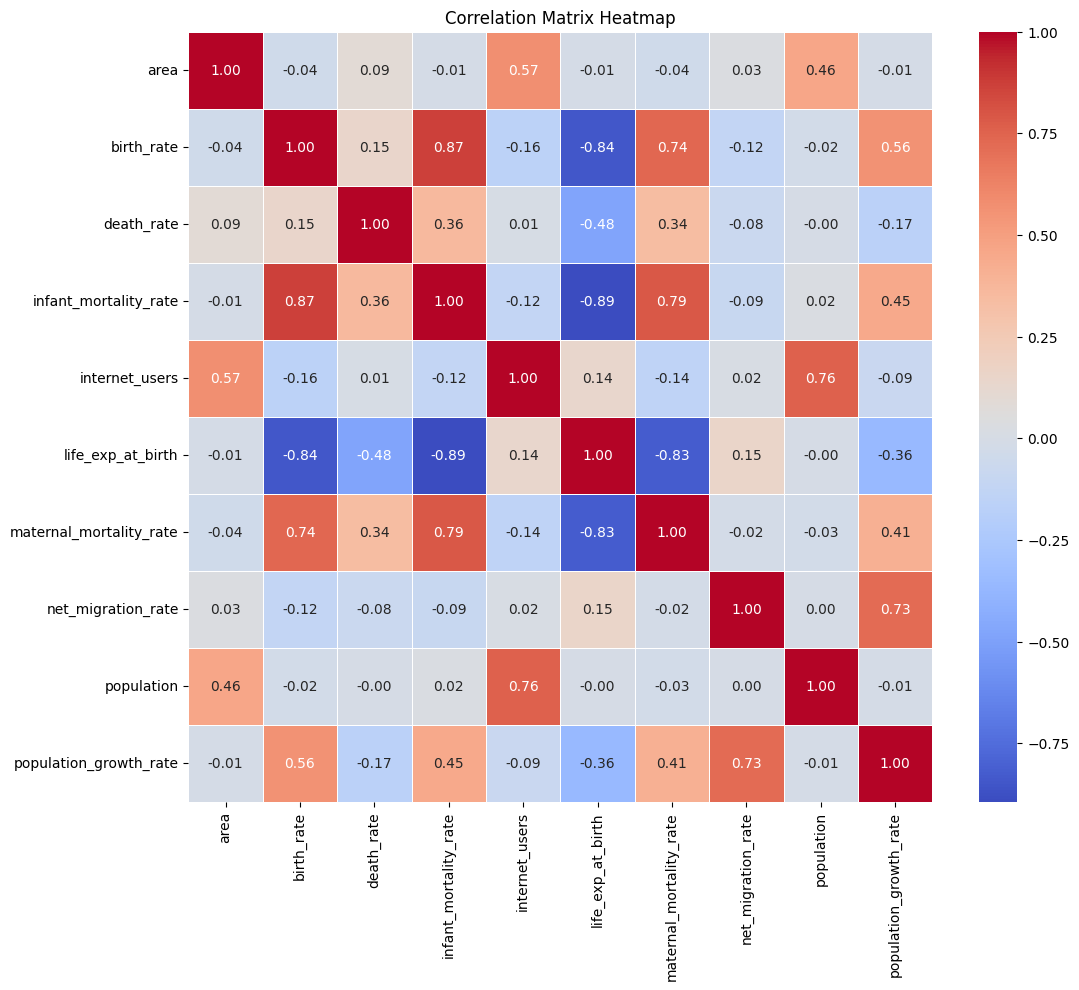

In [8]:
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix Heatmap')
plt.show()

In [9]:
highest_maternal_mortality = df.sort_values(by='maternal_mortality_rate', ascending=False)
display(highest_maternal_mortality[['country', 'maternal_mortality_rate']].head(10))

,country,maternal_mortality_rate
41,South Sudan,2054.0
20,Chad,1100.0
43,Somalia,1000.0
44,Central African Republic,890.0
118,Sierra Leone,890.0
145,Burundi,800.0
136,Guinea-Bissau,790.0
103,Liberia,770.0
15,Sudan,730.0
53,Cameroon,690.0


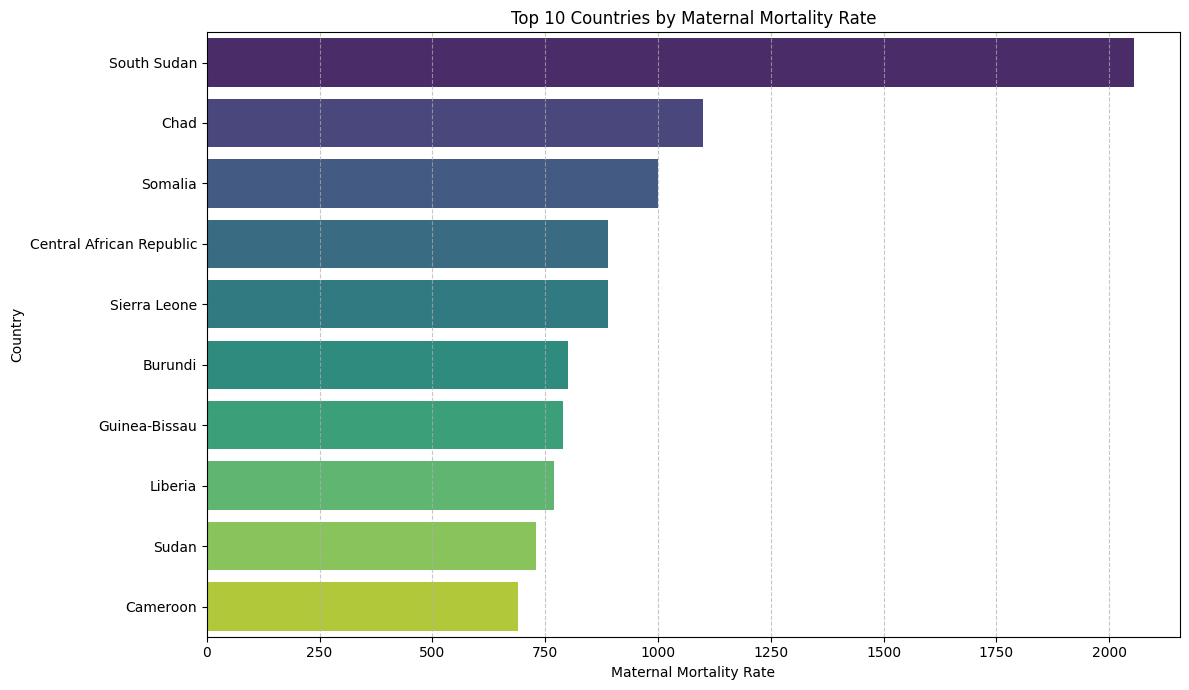

In [10]:
plt.figure(figsize=(12, 7))
sns.barplot(x='maternal_mortality_rate', y='country', data=highest_maternal_mortality.head(10), palette='viridis', hue='country', legend=False)
plt.title('Top 10 Countries by Maternal Mortality Rate')
plt.xlabel('Maternal Mortality Rate')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

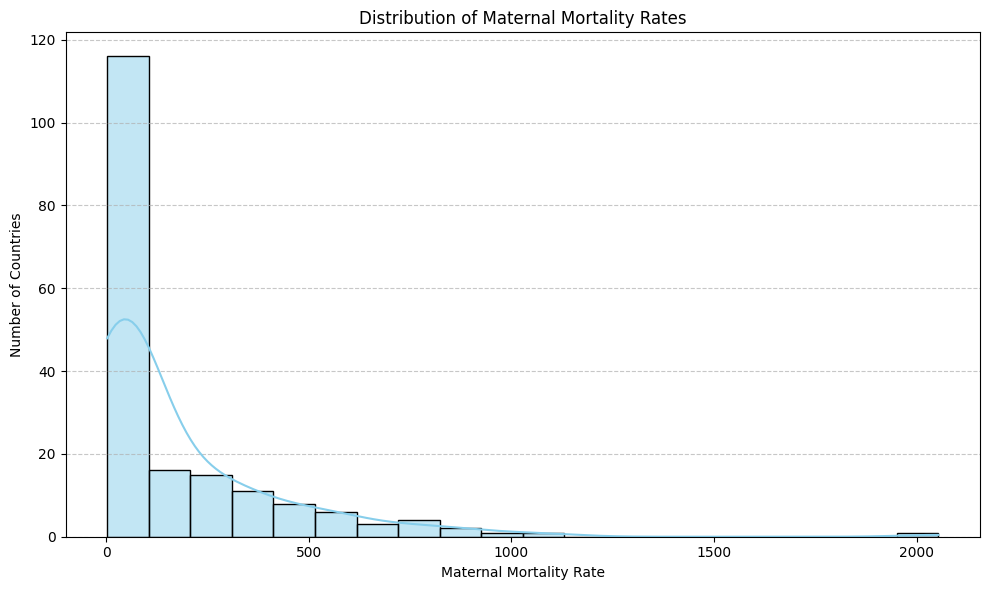

In [11]:
plt.figure(figsize=(10, 6))
sns.histplot(df['maternal_mortality_rate'].dropna(), bins=20, kde=True, color='skyblue')
plt.title('Distribution of Maternal Mortality Rates')
plt.xlabel('Maternal Mortality Rate')
plt.ylabel('Number of Countries')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [12]:
lowest_life_expectancy = df.sort_values(by='life_exp_at_birth', ascending=True)
display(lowest_life_expectancy[['country', 'life_exp_at_birth']].head(10))

,country,life_exp_at_birth
20,Chad,49.44
24,South Africa,49.56
136,Guinea-Bissau,49.87
40,Afghanistan,50.49
157,Swaziland,50.54
44,Central African Republic,51.35
43,Somalia,51.58
38,Zambia,51.83
33,Namibia,51.85
76,Gabon,52.06


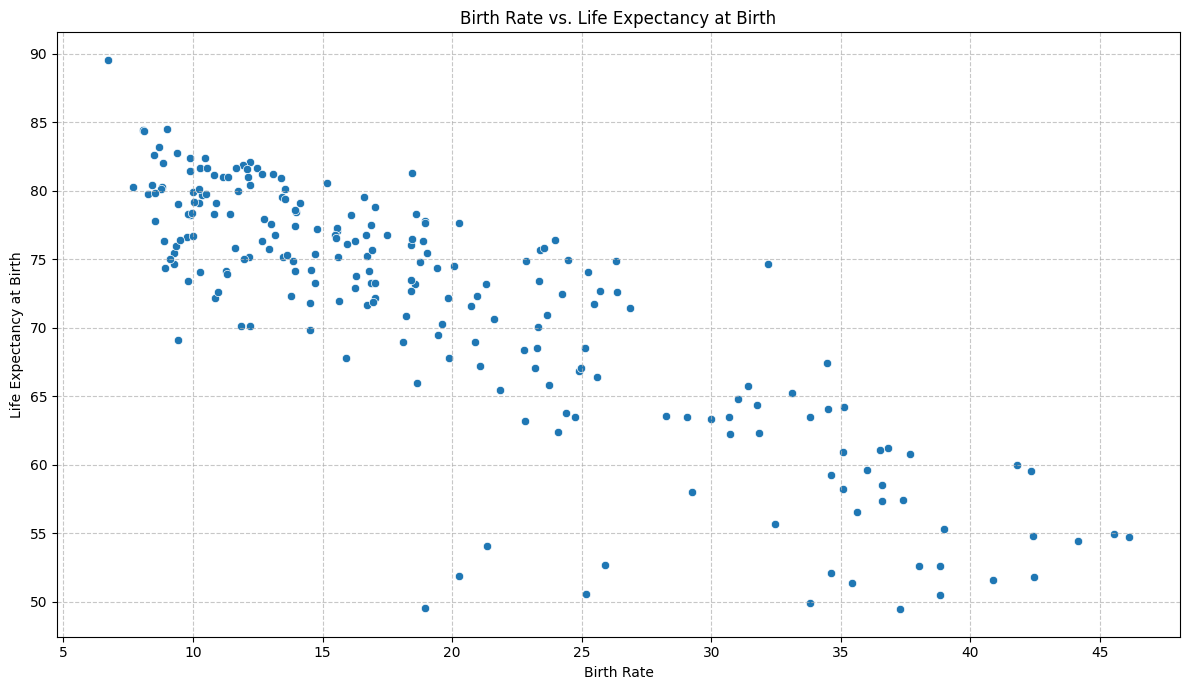

In [13]:
plt.figure(figsize=(12, 7))
sns.scatterplot(x='birth_rate', y='life_exp_at_birth', data=df)

plt.title('Birth Rate vs. Life Expectancy at Birth')
plt.xlabel('Birth Rate')
plt.ylabel('Life Expectancy at Birth')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [14]:
highest_internet_usage = df.sort_values(by='internet_users', ascending=False)
display(highest_internet_usage[['country', 'internet_users']].head(10))

,country,internet_users
3,China,389000000.0
2,United States,245000000.0
61,Japan,99182000.0
4,Brazil,75982000.0
62,Germany,65125000.0
6,India,61338000.0
79,United Kingdom,51444000.0
42,France,45262000.0
0,Russia,40853000.0
108,"Korea, South",39400000.0


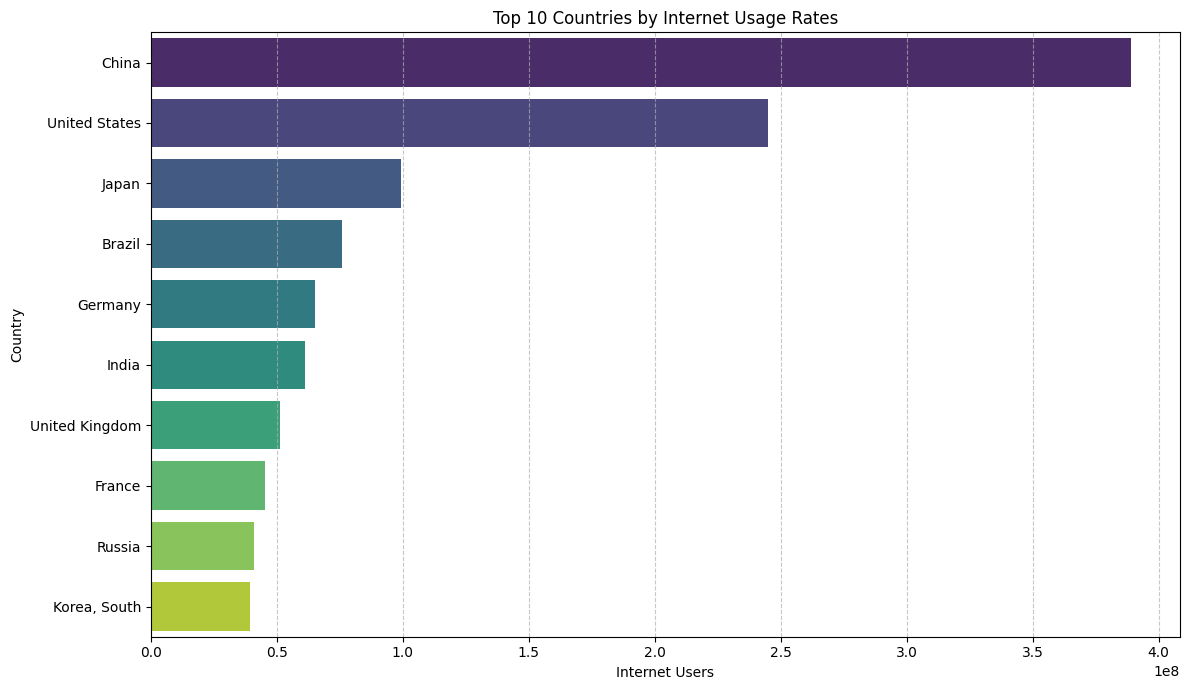

In [15]:
plt.figure(figsize=(12, 7))
sns.barplot(x='internet_users', y='country', data=highest_internet_usage.head(10), palette='viridis', hue='country', legend=False)

plt.title('Top 10 Countries by Internet Usage Rates')
plt.xlabel('Internet Users')
plt.ylabel('Country')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [16]:
internet_life_exp_correlation = correlation_matrix.loc['internet_users', 'life_exp_at_birth']
print(f"The correlation between internet users and life expectancy at birth is: {internet_life_exp_correlation:.2f}")

The correlation between internet users and life expectancy at birth is: 0.14


### Deep Learning Model: Data Preparation

To build a Deep Learning model, we first need to prepare our data. This involves selecting features (input variables) and targets (output variables), handling missing values, and scaling the data for optimal model performance.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
import numpy as np

# Define features (X) and target (y) columns
feature_cols = ['birth_rate', 'death_rate', 'infant_mortality_rate', 'maternal_mortality_rate', 'net_migration_rate', 'population']
target_cols = ['internet_users', 'life_exp_at_birth']

# Create a working DataFrame with only relevant columns, dropping rows with any missing values
df_model = df[feature_cols + target_cols].dropna()

X = df_model[feature_cols]
y = df_model[target_cols]

# Display the shape of the preprocessed data
print(f"Shape of features (X): {X.shape}")
print(f"Shape of targets (y): {y.shape}")

Shape of features (X): (177, 6)
Shape of targets (y): (177, 2)


### Feature Scaling and Train-Test Split

Deep Learning models often benefit from scaled input data. We'll use `StandardScaler` for features and `MinMaxScaler` for targets (since they are numerical outputs that we want to normalize). Then, we split the data into training and testing sets.

In [18]:
# Scale features
scaler_X = StandardScaler()
X_scaled = scaler_X.fit_transform(X)

# Scale targets
scaler_y = MinMaxScaler()
y_scaled = scaler_y.fit_transform(y)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (141, 6)
X_test shape: (36, 6)
y_train shape: (141, 2)
y_test shape: (36, 2)


### Deep Learning Model Architecture

Now we'll define a simple feed-forward neural network using TensorFlow/Keras for our multi-output regression task. The model will have multiple dense layers and an output layer matching the number of target variables.

In [19]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Define the model
model = Sequential([
    Dense(128, activation='relu', input_shape=(X_train.shape[1],)), # Input layer
    Dense(64, activation='relu'),
    Dense(32, activation='relu'),
    Dense(y_train.shape[1]) # Output layer with 2 units for 'internet_users' and 'life_exp_at_birth'
])

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mae'])

# Display the model summary
model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,298 (44.13 KB)

 Trainable params: 11,298 (44.13 KB)

 Non-trainable params: 0 (0.00 B)

### Model Training

We will now train the defined Deep Learning model using our scaled training data. The training process will involve iterating over the data multiple times (epochs) to optimize the model's weights.

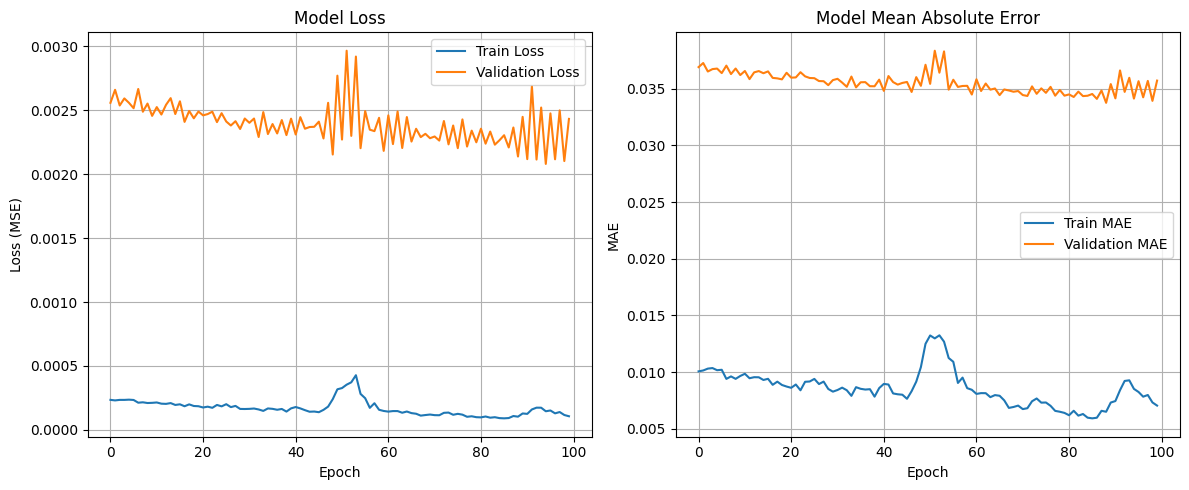

In [22]:
# Train the model
history = model.fit(X_train, y_train,
                    epochs=100, # Number of training iterations
                    batch_size=32, # Number of samples per gradient update
                    validation_split=0.2, # Use 20% of training data for validation
                    verbose=0) # Suppress verbose output for cleaner display

# Plot training history (loss and MAE)
plt.figure(figsize=(12, 5))

# Plot training & validation loss values
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

# Plot training & validation MAE values
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model Mean Absolute Error')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Model Evaluation

After training, we evaluate the model's performance on the unseen test data to see how well it generalizes.

In [23]:
# Evaluate the model on the test data
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (MSE): {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

# Make predictions on the test set
y_pred_scaled = model.predict(X_test)

# Inverse transform the predictions and actual values to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

# Display some actual vs. predicted values for 'internet_users'
print("\n--- Internet Users Predictions (Original Scale) ---")
for i in range(5):
    print(f"Actual: {y_test_actual[i, 0]:.0f}, Predicted: {y_pred[i, 0]:.0f}")

# Display some actual vs. predicted values for 'life_exp_at_birth'
print("\n--- Life Expectancy at Birth Predictions (Original Scale) ---")
for i in range(5):
    print(f"Actual: {y_test_actual[i, 1]:.2f}, Predicted: {y_pred[i, 1]:.2f}")

Test Loss (MSE): 0.0099
Test MAE: 0.0510
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step

--- Internet Users Predictions (Original Scale) ---
Actual: 115900, Predicted: -12985553
Actual: 17483000, Predicted: 39065672
Actual: 25900, Predicted: 10592360
Actual: 613600, Predicted: -4309284
Actual: 8278000, Predicted: 15227048

--- Life Expectancy at Birth Predictions (Original Scale) ---
Actual: 54.74, Predicted: 50.94
Actual: 74.18, Predicted: 77.33
Actual: 62.40, Predicted: 62.18
Actual: 52.60, Predicted: 51.46
Actual: 72.48, Predicted: 73.50


### Model Training

We will now train the defined Deep Learning model using our scaled training data. The training process will involve iterating over the data multiple times (epochs) to optimize the model's weights.

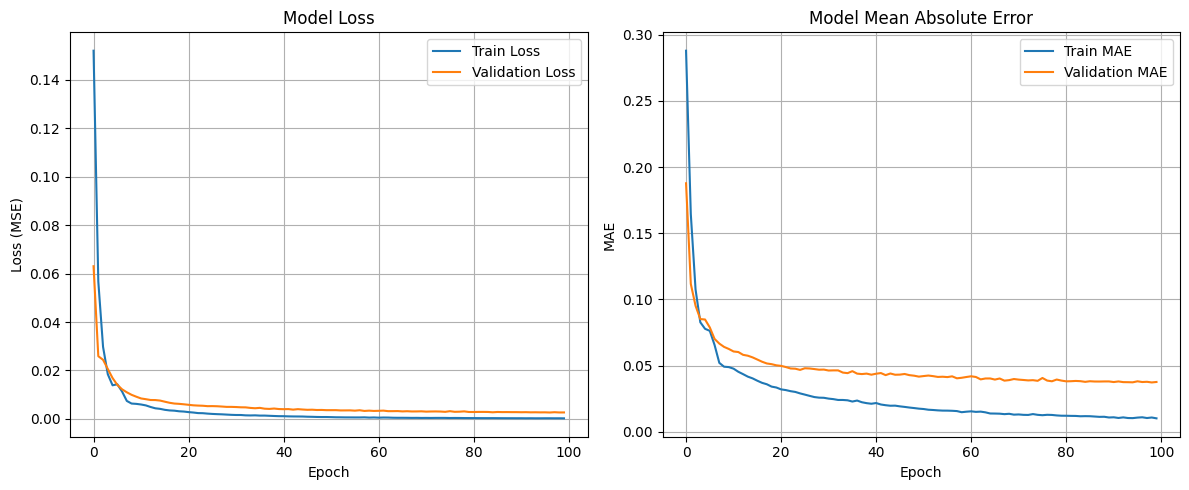

In [20]:
# Train the model
history = model.fit(X_train, y_train,
                    epochs=100, # Number of training iterations
                    batch_size=32, # Number of samples per gradient update
                    validation_split=0.2, # Use 20% of training data for validation
                    verbose=0) # Suppress verbose output for cleaner display

# Plot training history (loss and MAE)
plt.figure(figsize=(12, 5))

# Plot training & validation loss values
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.ylabel('Loss (MSE)')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

# Plot training & validation MAE values
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Validation MAE')
plt.title('Model Mean Absolute Error')
plt.ylabel('MAE')
plt.xlabel('Epoch')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Model Evaluation

After training, we evaluate the model's performance on the unseen test data to see how well it generalizes.

In [21]:
# Evaluate the model on the test data
loss, mae = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss (MSE): {loss:.4f}")
print(f"Test MAE: {mae:.4f}")

# Make predictions on the test set
y_pred_scaled = model.predict(X_test)

# Inverse transform the predictions and actual values to original scale
y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test)

# Display some actual vs. predicted values for 'internet_users'
print("\n--- Internet Users Predictions (Original Scale) ---")
for i in range(5):
    print(f"Actual: {y_test_actual[i, 0]:.0f}, Predicted: {y_pred[i, 0]:.0f}")

# Display some actual vs. predicted values for 'life_exp_at_birth'
print("\n--- Life Expectancy at Birth Predictions (Original Scale) ---")
for i in range(5):
    print(f"Actual: {y_test_actual[i, 1]:.2f}, Predicted: {y_pred[i, 1]:.2f}")

Test Loss (MSE): 0.0122
Test MAE: 0.0524
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step

--- Internet Users Predictions (Original Scale) ---
Actual: 115900, Predicted: -5006370
Actual: 17483000, Predicted: 39240636
Actual: 25900, Predicted: 11297196
Actual: 613600, Predicted: -364350
Actual: 8278000, Predicted: 10788579

--- Life Expectancy at Birth Predictions (Original Scale) ---
Actual: 54.74, Predicted: 51.48
Actual: 74.18, Predicted: 77.70
Actual: 62.40, Predicted: 62.88
Actual: 52.60, Predicted: 51.69
Actual: 72.48, Predicted: 73.31
